# First Implementation 


There is the Pipeline 
**camera.py** : construit les intrinseques pour chaque niveau de pyramide
**frameData.py** : stocke image, derivees, inverse depth et pose
**pose_estimator_gauss_newton.py** : optimise la pose
**common.py** : interpolation bilineaire
**dataset/desktop_dataset/images** : les images
**Depth-Anything** : calcule les depth maps a la volee depuis les images




Dans ce notebook, on travaille volontairement sur **un exemple simple** :
**scene_000** = keyframe
**scene_001** = image courante par defaut

Tu pourras changer la variable **TARGET_INDEX** plus bas si tu veux tester un autre cas.


In [1]:
from pathlib import Path
import copy
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

import camera
import common
import frameData
import pose_estimator_gauss_newton


In [2]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent
DATASET_DIR = ROOT / "dataset" / "desktop_dataset"
IMAGE_DIR = DATASET_DIR / "images"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything introuvable: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize

KEYFRAME_INDEX = 0
TARGET_INDEX = 1
DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = DATASET_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT =", ROOT)
print("DATASET_DIR =", DATASET_DIR)
print("DEPTH_ANYTHING_DIR =", DEPTH_ANYTHING_DIR)
print("DEPTH_CACHE_DIR =", DEPTH_CACHE_DIR)
print("DEVICE =", DEVICE)
print("DEPTH_MODEL_NAME =", DEPTH_MODEL_NAME)
print("KEYFRAME_INDEX =", KEYFRAME_INDEX)
print("TARGET_INDEX =", TARGET_INDEX)


ROOT = c:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\python_visual_odometry
DATASET_DIR = c:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\python_visual_odometry\dataset\desktop_dataset
DEPTH_ANYTHING_DIR = c:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\Depth-Anything
DEPTH_CACHE_DIR = c:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\python_visual_odometry\dataset\desktop_dataset\depth_anything_cache\vitb
DEVICE = cpu
DEPTH_MODEL_NAME = LiheYoung/depth_anything_vitb14
KEYFRAME_INDEX = 0
TARGET_INDEX = 1


c:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Fonctions utilitaires du notebook

On re-ecrit ici quelques petites fonctions pour rendre le pipeline explicite :

- charger une image en niveaux de gris
- calculer une depth map avec Depth Anything
- convertir depth -> inverse depth
- afficher rapidement une matrice 4x4

La depth n'est plus lue depuis `dataset/desktop_dataset/depth`.
Elle est inferree directement a partir de l'image correspondante avec l'encodeur `vitb`, puis optionnellement mise en cache dans `dataset/desktop_dataset/depth_anything_cache/vitb` pour eviter de recalculer a chaque execution.

La conversion importante est :

$$
\rho = \frac{1}{d}
$$

ou **d** est la depth et **rho** l'inverse depth attendue par le solveur.


In [3]:
def load_gray_image(index: int) -> np.ndarray:
    path = IMAGE_DIR / f"scene_{index:03d}.png"
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image introuvable: {path}")
    return image


def load_rgb_image(index: int) -> np.ndarray:
    path = IMAGE_DIR / f"scene_{index:03d}.png"
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image introuvable: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything charge sur {DEVICE} ({total_params / 1e6:.2f}M parametres)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(index: int, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    cache_path = DEPTH_CACHE_DIR / f"scene_{index:03d}_depth.npy"
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(index).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


## 3. Chargement du keyframe et de sa depth

Ici on charge :

- l'image de reference **scene_000**
- la depth map inferree par **Depth Anything** pour `scene_000`

C'est cette image qui fournit la geometrie 3D de base.


In [4]:
keyframe_image = load_gray_image(KEYFRAME_INDEX)
keyframe_depth = load_depth_map(KEYFRAME_INDEX)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)

print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image shape = (480, 640) dtype = uint8
keyframe_depth shape = (480, 640) dtype = float32
depth min/max = 3.449415922164917 75.60169219970703
valid depth ratio = 1.0


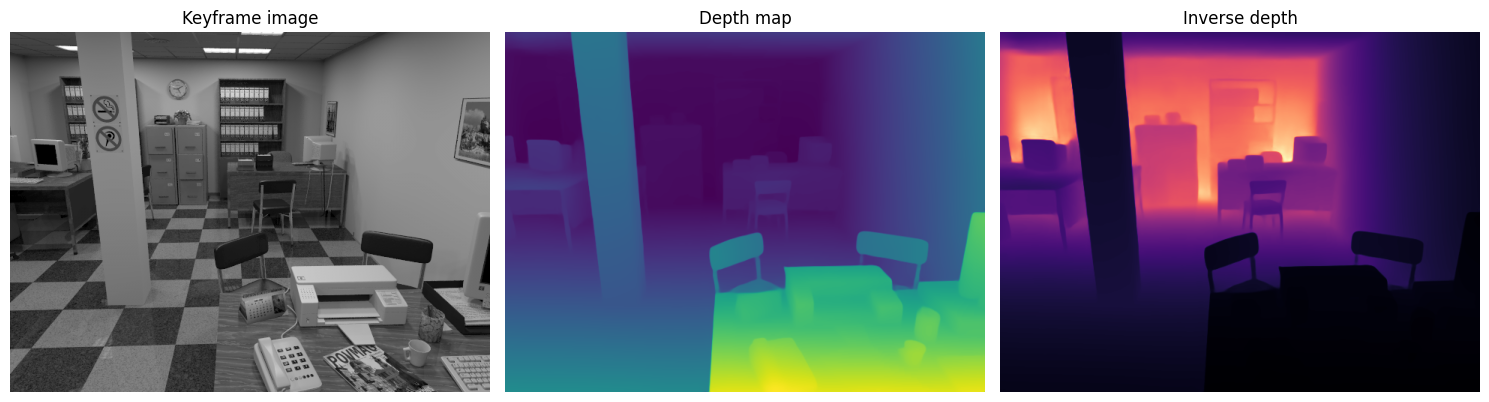

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")
axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")
axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Construction du keyframe **frameData**

**frameData** cree une pyramide multi-echelle :

- image niveau 0, 1, 2, 3, 4
- derivees spatiales de chaque niveau
- inverse depth et variance pour chaque niveau

En pratique :
**setImage(...)** construit la pyramide de l'image
**setInvDepth(...)** redimensionne aussi l'inverse depth sur chaque niveau


In [6]:
width = 640
height = 480
fx = 481.20
fy = 480.0
cx = 319.5
cy = 239.5

cam = camera.camera(fx, fy, cx, cy, width, height)


In [7]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(512, 512), invDepth=(512, 512), grad=(512, 512, 2)
level 1: image=(256, 256), invDepth=(256, 256), grad=(256, 256, 2)
level 2: image=(128, 128), invDepth=(128, 128), grad=(128, 128, 2)
level 3: image=(64, 64), invDepth=(64, 64), grad=(64, 64, 2)
level 4: image=(32, 32), invDepth=(32, 32), grad=(32, 32, 2)


## 5. Chargement de l'image courante

Maintenant on prend une deuxieme image.

C'est elle dont on veut estimer la pose relative par rapport au keyframe.
Au debut, sa pose est l'identite, puis le solveur va la mettre a jour.


In [8]:
current_image = load_gray_image(TARGET_INDEX)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



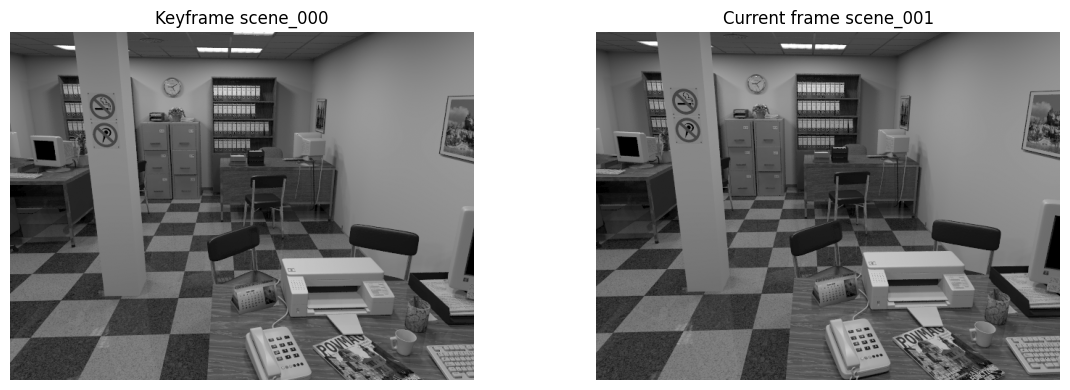

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe scene_{KEYFRAME_INDEX:03d}")
axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame scene_{TARGET_INDEX:03d}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Que veut dire **estimer la pose** ici ?

Pour chaque pixel du keyframe :

1. on utilise l'inverse depth pour remonter au point 3D
2. on applique une pose candidate
3. on reprojette ce point dans l'image courante
4. on compare l'intensite predite et l'intensite observee

Le solveur essaye donc de minimiser une erreur photometrique.

Si la pose est correcte, les points reprojectes tombent aux bons endroits dans l'image courante.


In [10]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Initial photometric errors before optimization:
  level 4 = 1041.822272215973
  level 3 = 1065.0378787878783
  level 2 = 1112.7102656319005


## 7. Optimisation de pose

C'est ici que la pose est reellement calculee.

**optPose(...)** fait plusieurs mises a jour :

- il calcule une erreur
- il linearise localement le probleme
- il calcule un increment de pose
- il accepte ou rejette cette mise a jour selon l'amelioration de l'erreur

A la fin, **current_frame.pose** contient la matrice extrinseque estimee du frame courant par rapport au keyframe.


In [11]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  1041.822272215973
 error improvement too small, level converged! it:  4  error:  718.67432978136  lambda:  0.2
lvl:  3  initial error:  503.6190768758534
 error improvement too small, level converged! it:  4  error:  370.495627861996  lambda:  0.8
lvl:  2  initial error:  249.21566721390957
 error improvement too small, level converged! it:  2  error:  239.45844579691123  lambda:  54975581388.8
Final photometric errors after optimization:
  level 4 = 737.3066283515408
  level 3 = 375.27423390997296
  level 2 = 239.45844579691123


## 8. La matrice extrinseque finale

C'est la sortie la plus importante du notebook.

Cette matrice 4x4 represente la pose relative estimee de l'image courante par rapport au keyframe.

Sous forme bloc :

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$

avec :
**R** = rotation **3x3**
**t** = translation **3x1**


In [12]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for scene_{TARGET_INDEX:03d} relative to scene_{KEYFRAME_INDEX:03d}:",
    current_frame.pose,
)

rotation_matrix = extrinsic_matrix[:3, :3]
translation_vector = extrinsic_matrix[:3, 3]


Extrinsic matrix for scene_001 relative to scene_000:
[[ 0.999922  0.001695 -0.012373  0.044215]
 [-0.001893  0.99987  -0.015985  0.038377]
 [ 0.012344  0.016007  0.999796  0.042359]
 [ 0.        0.        0.        1.      ]]


In [13]:

print("\nRotation matrix:")
print(rotation_matrix)

print("\nTranslation vector:")
print(translation_vector)



Rotation matrix:
[[ 0.999922  0.001695 -0.012373]
 [-0.001893  0.99987  -0.015985]
 [ 0.012344  0.016007  0.999796]]

Translation vector:
[0.044215 0.038377 0.042359]


----------- 

## Evaluation 
Maintenant que la pose est estimee, on peut faire la comparaison la plus concrete possible :

- pour chaque pixel du keyframe
- on le reprojette dans l'image courante avec la pose finale
- on compare l'intensite du keyframe et l'intensite observee dans l'image 2

Cela nous donne une **carte de differences** directement interpretable.


In [14]:
def compute_photometric_maps(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    predicted_map = np.full((height, width), np.nan, dtype=np.float32)
    true_map = np.full((height, width), np.nan, dtype=np.float32)
    signed_diff_map = np.full((height, width), np.nan, dtype=np.float32)
    abs_diff_map = np.full((height, width), np.nan, dtype=np.float32)
    squared_diff_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)



    #y est l'index de ligne et x l'index de colonne
    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)
            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))

            predicted_map[y, x] = key_intensity
            true_map[y, x] = observed_intensity
            signed_diff_map[y, x] = key_intensity - observed_intensity
            abs_diff_map[y, x] = abs(key_intensity - observed_intensity)
            squared_diff_map[y, x] = (key_intensity - observed_intensity) ** 2
            valid_mask[y, x] = True

    return {
        "predicted_map": predicted_map,
        "true_map": true_map,
        "signed_diff_map": signed_diff_map,
        "abs_diff_map": abs_diff_map,
        "squared_diff_map": squared_diff_map,
        "valid_mask": valid_mask,
    }


photometric_maps = compute_photometric_maps(current_frame, keyframe, cam, lvl=0)
valid_pixels = photometric_maps["valid_mask"].sum()
print("Number of valid reprojected pixels =", int(valid_pixels))


Number of valid reprojected pixels = 254278


**Métrique**

Voici les cartes utiles :

**difference signee** : positive ou negative selon que le keyframe est plus clair ou plus sombre
**difference absolue** : plus c'est rouge, plus l'erreur d'intensite est forte
**difference au carre** : penalise encore plus les grosses erreurs


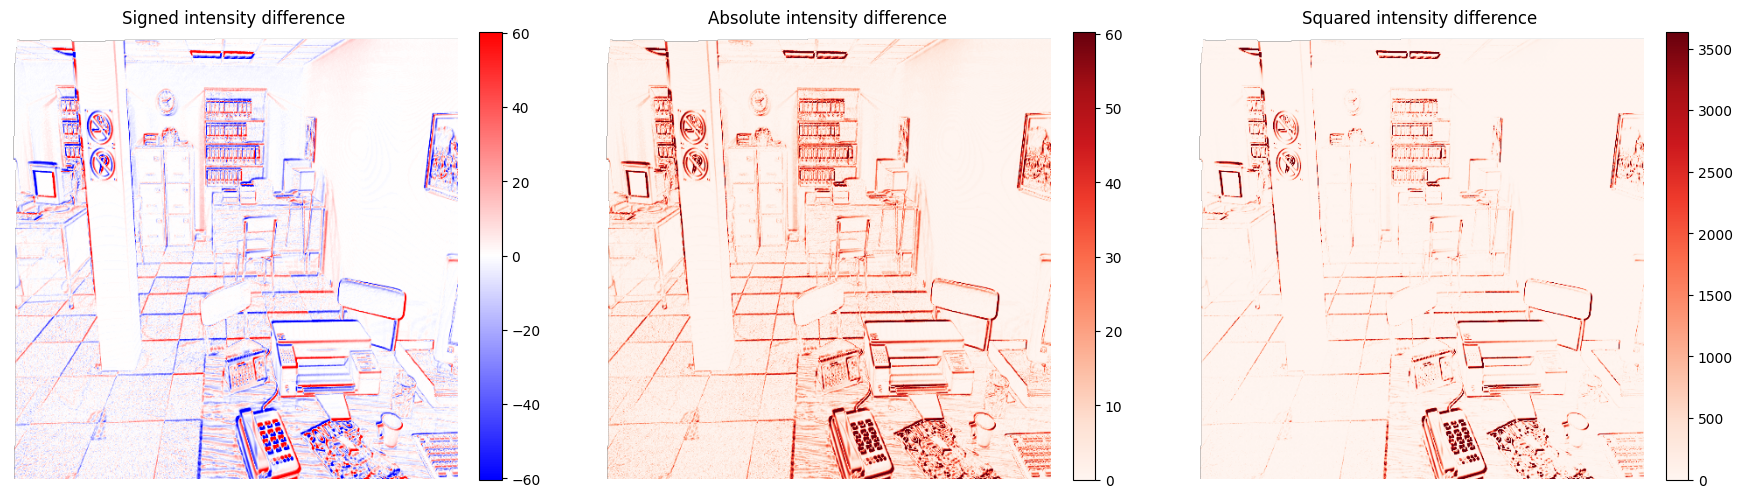

In [15]:
signed_diff_map = photometric_maps["signed_diff_map"]
abs_diff_map = photometric_maps["abs_diff_map"]
squared_diff_map = photometric_maps["squared_diff_map"]
valid_mask = photometric_maps["valid_mask"]

valid_signed = signed_diff_map[valid_mask]
vmax_signed = float(np.nanpercentile(np.abs(valid_signed), 99))
vmax_abs = float(np.nanpercentile(abs_diff_map[valid_mask], 99))
vmax_sq = float(np.nanpercentile(squared_diff_map[valid_mask], 99))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(signed_diff_map, cmap="bwr", vmin=-vmax_signed, vmax=vmax_signed)
axes[0].set_title("Signed intensity difference")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(abs_diff_map, cmap="Reds", vmin=0, vmax=vmax_abs)
axes[1].set_title("Absolute intensity difference")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(squared_diff_map, cmap="Reds", vmin=0, vmax=vmax_sq)
axes[2].set_title("Squared intensity difference")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [16]:
print("Difference metrics on valid pixels:")

print("")
print("  mean signed difference   =", float(np.nanmean(signed_diff_map)))
print("  mean absolute difference =", float(np.nanmean(abs_diff_map)))
print("  mean squared difference  =", float(np.nanmean(squared_diff_map)))
print("  max absolute difference  =", float(np.nanmax(abs_diff_map)))
print("  max squared difference   =", float(np.nanmax(squared_diff_map)))


Difference metrics on valid pixels:

  mean signed difference   = 0.014451341703534126
  mean absolute difference = 6.097346782684326
  mean squared difference  = 185.32298278808594
  max absolute difference  = 180.59481811523438
  max squared difference   = 32614.490234375
